In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

c:\Users\hieno\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df.job_posted_date = pd.to_datetime(df.job_posted_date)
df.job_skills = df.job_skills.apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## 🟩 Top Companies Bar Plot (2.20.1) - Problem

Create a Seaborn bar plot to visualize the top 5 companies with the highest median salary_year_avg for Data Scientist job postings in the United States.

In [45]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()

df_DS_US = df_DS_US.dropna(subset='salary_year_avg')

top_5_companies = df_DS_US.groupby('company_name')['salary_year_avg'].agg(['median']).sort_values(by='median', ascending=False)


top_5_companies = top_5_companies.nlargest(5, columns='median').reset_index()

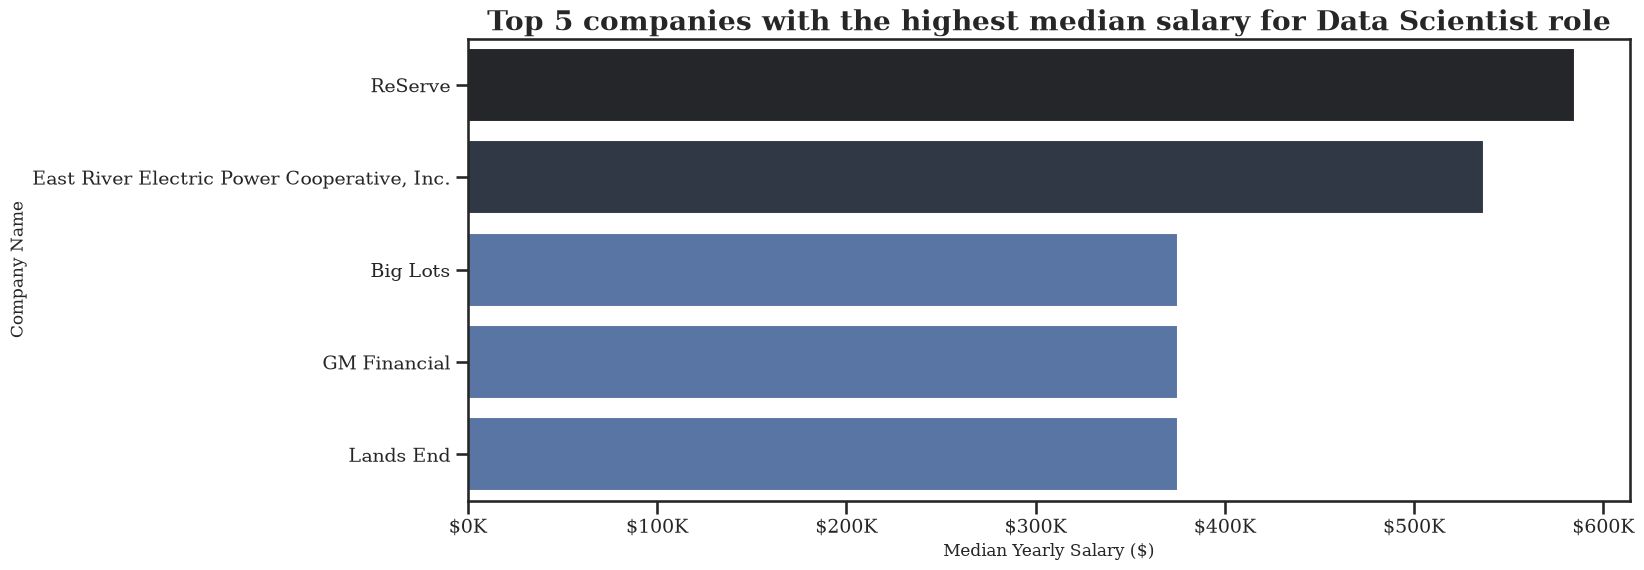

In [55]:
fig, ax = plt.subplots(figsize = (15, 6))

sns.set_theme(
                style='ticks'
                , palette = 'deep'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.85)

sns.barplot(
            data = top_5_companies
            , x = 'median'
            , y = top_5_companies['company_name'].values
            , hue = 'median'
            , palette= 'dark:b_r')

plt.title(
            'Top 5 companies with the highest median salary for Data Scientist role'
            , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.ylabel(
            'Company Name'
            , fontdict={'fontsize': 12})

plt.xlabel(
            'Median Yearly Salary ($)'
            , fontdict={'fontsize': 12})

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000):,}K'))

plt.legend().remove()
plt.show()

## 🟨 Data Scientist Salary Histogram (2.20.2) - Problem

Create a histogram using Seaborn to visualize the distribution of average yearly salaries (use the salary_year_avg column) for Data Scientist job postings in the United States:

* Filter the DataFrame to include only job postings in the United States and remove any entries with missing yearly salary values.
* Use 25 bins for the histogram and set the x-axis limit to 700,000.
* Set the title to 'Distribution of Yearly Salaries for Data Scientist in the United States' and label the y-axis 'Number of Jobs' and x-axis 'Yearly Salary (USD)'.

In [57]:
df_US_DS = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()

df_US_DS = df_US_DS.dropna(subset='salary_year_avg')

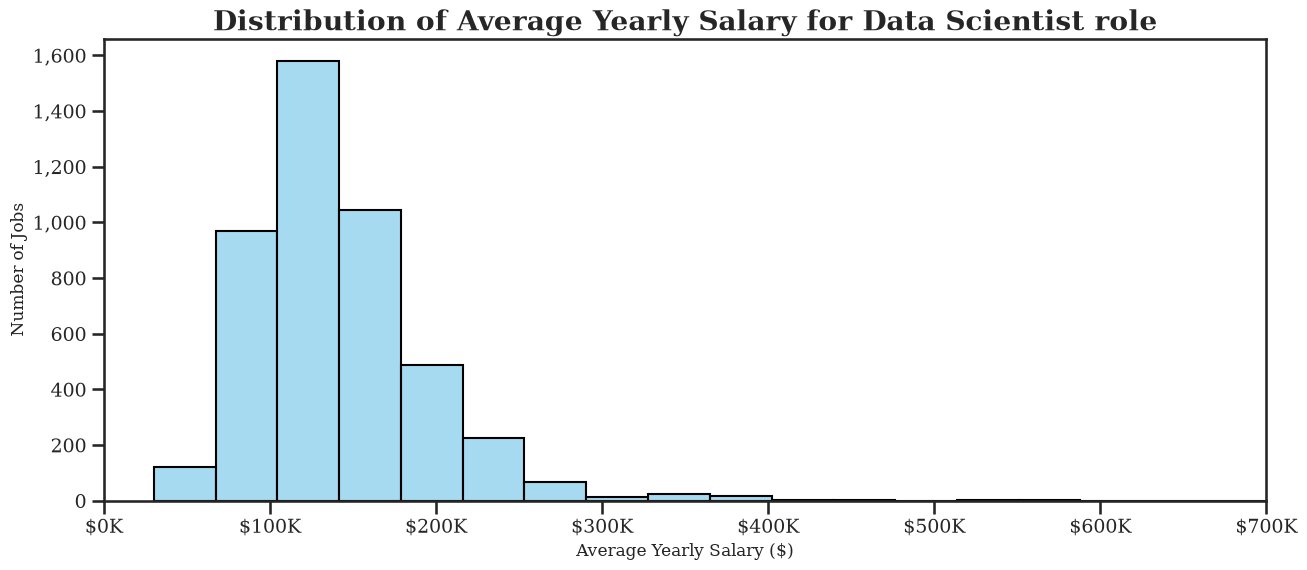

In [98]:
fig, ax = plt.subplots(figsize = (15, 6))

sns.set_theme(
                style='ticks'
                , palette = 'deep'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.85)

sns.histplot(
            data = df_US_DS
            , x = 'salary_year_avg'
            , bins=25
            , kde = False
            , edgecolor = 'black'
            , color="skyblue"
            , multiple='dodge'
            , common_norm = True)

plt.title(
            'Distribution of Average Yearly Salary for Data Scientist role'
            , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.ylabel(
            'Number of Jobs'
            , fontdict={'fontsize': 12})

plt.xlabel(
            'Average Yearly Salary ($)'
            , fontdict={'fontsize': 12})

plt.xlim(0, 700000)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000):,}K'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y):,}'))

plt.show()


## 🟨 Data Roles Salary Box Plot (2.20.3) - Problem

Create a box plot using Seaborn to compare the yearly salaries (use the salary_year_avg column) of Data Analyst, Data Engineer, and Data Scientist job postings in India:

* Filter the DataFrame to include only job postings in India and remove any entries with missing yearly salary values.
* Set the x-axis limit to 300,000 and format it as $100k.
* Set the title to 'Yearly Salary Comparison for Data Roles in India' and label the x-axis as 'Yearly Salary (USD)'.

In [99]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

In [100]:
df_Indi = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'India')].copy()

df_Indi = df_Indi.dropna(subset='salary_year_avg')

In [117]:
order = df_Indi.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending = False).index

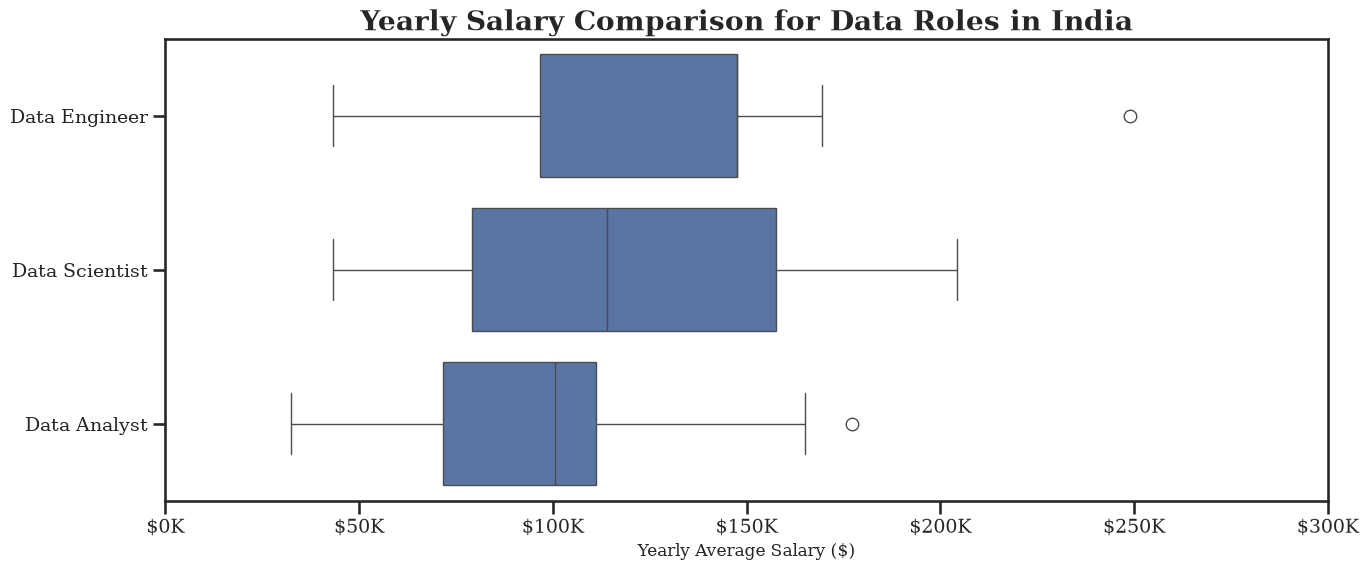

In [115]:
fig, ax = plt.subplots(figsize = (15, 6))

sns.set_theme(
                style='ticks'
                , palette = 'deep'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.85)

sns.boxplot(data = df_Indi
            , x = 'salary_year_avg'
            , y = 'job_title_short'
            , order = order)

plt.title(
            'Yearly Salary Comparison for Data Roles in India'
            , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.ylabel(
            ''
            , fontdict={'fontsize': 12})

plt.xlabel(
            'Yearly Average Salary ($)'
            , fontdict={'fontsize': 12})

plt.xlim(0, 300000)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000):,}K'))

plt.show()

## 🟨 Salary Distribution for United States (2.20.4) - Problem

* Create a violin plot using Seaborn to visualize the distribution of salary_year_avg for Data Scientist roles in the United States.
* Ensure the plot includes a title, axis labels, and custom formatting for the salary axis.

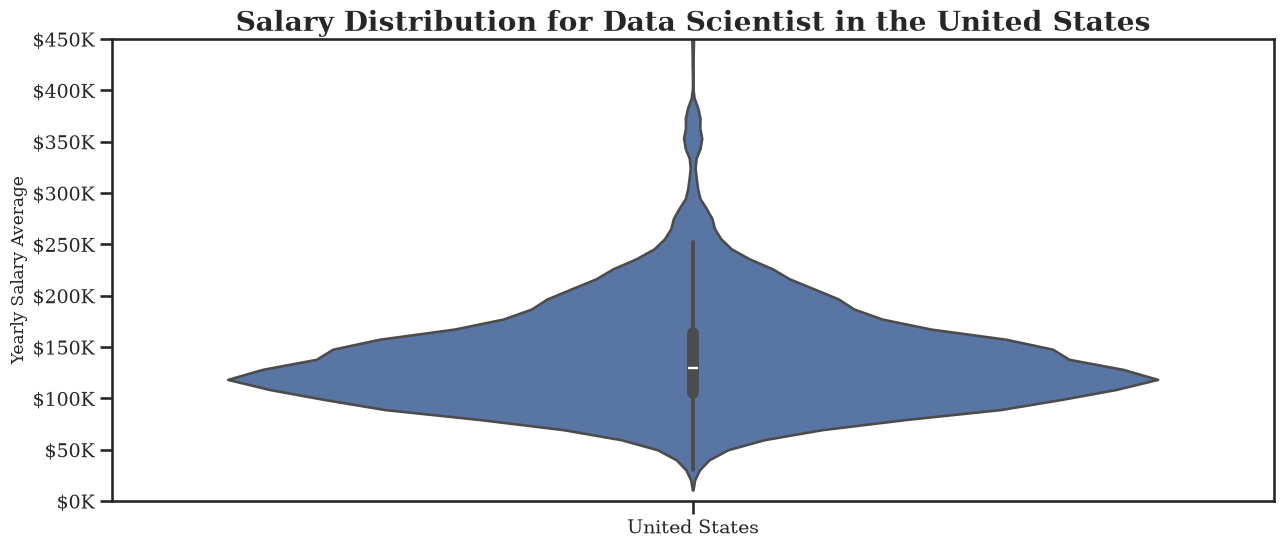

In [ ]:
fig, ax = plt.subplots(figsize = (15, 6))

sns.set_theme(
                style='ticks'
                , palette = 'deep'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.85)

sns.violinplot(
                data=df_DS_US
                , x = 'job_country'
                , y = 'salary_year_avg')

plt.title(
            'Salary Distribution for Data Scientist in the United States'
            , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.ylabel(
            'Yearly Salary Average'
            , fontdict={'fontsize': 12})

plt.xlabel(
            ''
            , fontdict={'fontsize': 12})

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000):,}K'))

plt.ylim(0, 450000) 

plt.show()